## Net generators

## Tipus de xarxes

### No geomètriques

- Erdos-Ranyi (no es scale-free, clustering baix)
- Barabasi-Albert (scale-free, clustering baix)
- Configuracional (clustering = 0)

### Geomètriques

- $\mathbb{S}^1\mathbb{H}^2$


## Equivalència de paràmetres

| Característica                                  | ER                      | BA                                   | Configuracional                                   | S1 / H2                 |
| ----------------------------------------------- | ----------------------- | ------------------------------------ | ------------------------------------------------- | ----------------------- |
| $N$                                             | $N$                     | $N$                                  | $N$                                               | $N$                     |
| Grau mig $\langle k \rangle$                    | $p=\frac{⟨k⟩}{N−1}$     | $m=\frac{⟨k⟩}{2}$​ (ha de ser enter) | En funció de la sequencia o distribució de graus. | $\langle k \rangle$     |
| Exponent de la distribució $\gamma$ (si aplica) | -                       | Fixat, $\gamma = 3$                  | Escollir $P(k) = k^{-\gamma}$                     | $\gamma$                |
| Clustering $C$                                  | Molt baix, no ajustable | Molt baix, no ajustable              | 0, no ajustable                                   | En funció de la $\beta$ |


In [2]:

g = 2.1
n = 1000
b = 2.1
k = 20
m = int(k/2)
p = k/(n-1)
seed = 12345


working_folder = f'./generated-nets'
s1h2_working_folder = f'{working_folder}/s1h2'
er_working_folder = f'{working_folder}/er'
ba_working_folder = f'{working_folder}/ba'
conf_working_folder = f'{working_folder}/config'

er_file = f'{er_working_folder}/er-n={n}-k={k}'
ba_file = f'{ba_working_folder}/ba-n={n}-k={k}'
conf_file = f'{conf_working_folder}/conf-n={n}-k={k}-g={g}'
s1h2_file = f'{s1h2_working_folder}/s1h2-n={n}-k={k}-g={g}-b={b}'

er_edges_file = f'{er_file}.edge'
ba_edges_file = f'{ba_file}.edge'
conf_edges_file = f'{conf_file}.edge'
s1h2_edges_file = f'{s1h2_file}.edge'


er_coords_file = f'{er_file}.inf_coord'
ba_coords_file = f'{ba_file}.inf_coord'
conf_coords_file = f'{conf_file}.inf_coord'
s1h2_coords_file = f'{s1h2_file}.inf_coord'


In [3]:
import re
import networkx as nx
from pathlib import Path
def generate_powerlaw_sequence_with_avg_k(n, gamma, target_k, k_max=100, tolerance=0.1, seed=12345):
    """
    Genera una secuencia de grados con γ fijo que se aproxime a <k> objetivo.
    """
    import numpy as np
    # Buscar k_min que dé el <k> deseado
    k_min = 1
    best_seq = None
    best_avg = 0
    rng = np.random.RandomState(seed)
    for k_min_candidate in range(1, 20):
        # Generar grados con este k_min
        degrees = []
        while len(degrees) < n:
            # Muestreo por transformada inversa
            r = rng.random()
            k = k_min_candidate * (1 - r) ** (-1/(gamma-1))
            if k <= k_max:
                degrees.append(int(np.floor(k)))
        
        # Ajustar para que la suma sea par (requisito del modelo de configuración)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1
        
        current_avg = np.mean(degrees)
        
        if abs(current_avg - target_k) < abs(best_avg - target_k):
            best_avg = current_avg
            best_seq = degrees
        
        if abs(current_avg - target_k) < tolerance:
            return degrees
    
    return best_seq

Gba = nx.barabasi_albert_graph(n, m, seed=seed)
sequence = generate_powerlaw_sequence_with_avg_k(n, gamma=g, target_k=k, seed=seed, tolerance=0.001)
Gconf = nx.configuration_model(sequence)
Ger = nx.erdos_renyi_graph(n, p, seed=seed)

! mkdir -p {s1h2_working_folder}
! mkdir -p {er_working_folder}
! mkdir -p {ba_working_folder}
! mkdir -p {conf_working_folder}

nx.write_edgelist(Gba, ba_edges_file, data=False)
nx.write_edgelist(Ger, er_edges_file, data=False)
nx.write_edgelist(Gconf, conf_edges_file, data=False)
! ./tools/genSD -d 1 -n {n} -g {g} -k {k} -b {b} -s {seed} -o {s1h2_file}
# remove v from node name
t = Path(s1h2_edges_file).read_text()
t = re.sub(r'v(\d)', r'\1', t)
Path(s1h2_edges_file).write_text(t)

Gs1h2 = nx.read_edgelist(s1h2_edges_file)

OUTPUT_ROOTNAME = /home/adria/universitat/epidemics-tfg-pipeline/./generated-nets/s1h2/s1h2-n=1000-k=20-g=2.1-b=2.1
edgelist_file = /home/adria/universitat/epidemics-tfg-pipeline/./generated-nets/s1h2/s1h2-n=1000-k=20-g=2.1-b=2.1.edge


# Generació

In [4]:
! ./tools/mercator -o {s1h2_file} -b {b} -s {seed} {s1h2_edges_file}
! ./tools/mercator -o {er_file} -b {b} -s {seed} {er_edges_file}
! ./tools/mercator -o {ba_file} -b {b} -s {seed} {ba_edges_file}
! ./tools/mercator -o {conf_file} -b {b} -s {seed} {conf_edges_file}


In [5]:
import pipeline.data as data

Gba, dfba, paramsba = data.read_hyperbolic_data(ba_coords_file, ba_edges_file)
Ger, dfer, paramser = data.read_hyperbolic_data(er_coords_file, er_edges_file)
Gconf, dfconf, paramsconf = data.read_hyperbolic_data(conf_coords_file, conf_edges_file)
Gs1h2 , dfs1h2, paramss1h2 = data.read_hyperbolic_data(s1h2_coords_file, s1h2_edges_file)

## Mapa

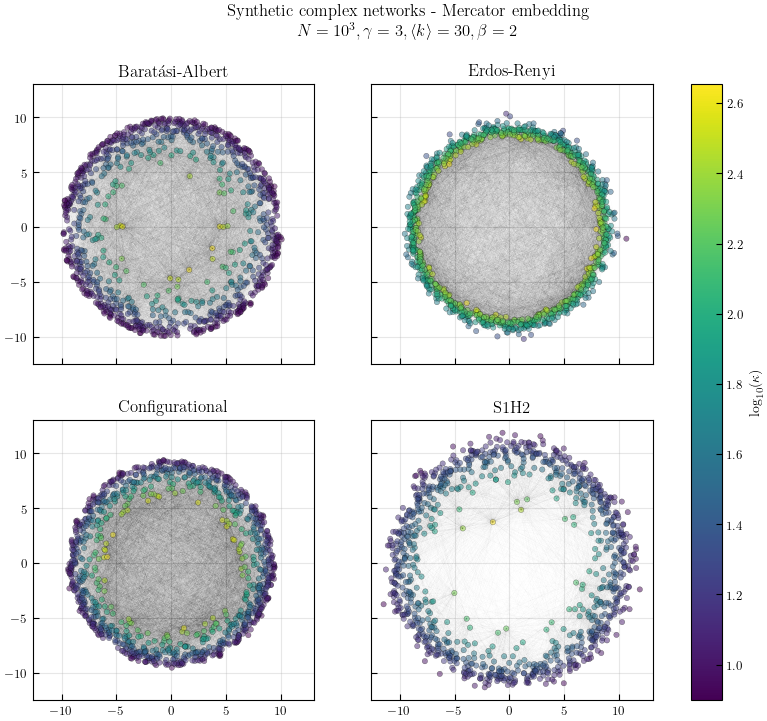

In [6]:
import pipeline.figures as figs
import matplotlib.pyplot as plt
import pipeline.init as init
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

init.configure_matplotlib()


fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8), dpi=100)
vmax = np.max(np.log10([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa'], dfs1h2['Inf.Kappa']]))
vmin = np.min(np.log10([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa'], dfs1h2['Inf.Kappa']]))

figs.mercator_disc_ax(ax1, dfba, net=Gba, title='Baratási-Albert')
figs.mercator_disc_ax(ax2, dfer, net=Ger, title='Erdos-Renyi')
figs.mercator_disc_ax(ax3, dfconf, net=Gconf, title='Configurational')
figs.mercator_disc_ax(ax4, dfs1h2, net=Gs1h2, title='S1H2')

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

# Añadir la colorbar
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], label=r'$\log_{10}(\kappa)$')
fig.suptitle('Synthetic complex networks - Mercator embedding\n$N=10^3, \\gamma=3, \\langle k \\rangle = 30, \\beta = 2$')
# fig.tight_layout()
plt.show()

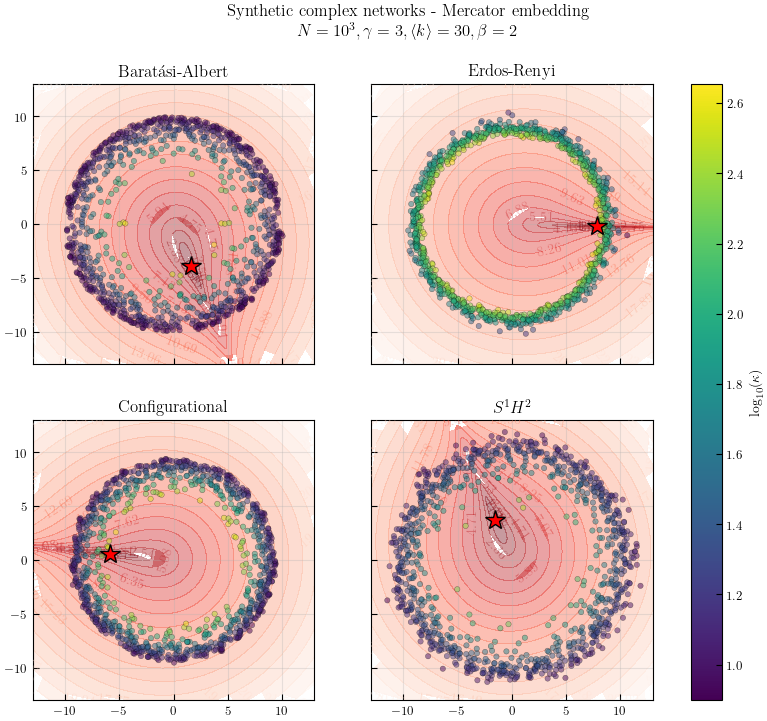

In [20]:
import pipeline.figures as figs
import matplotlib.pyplot as plt
import pipeline.init as init
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import numpy as np

init.configure_matplotlib()


fig, axes = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(10, 8), dpi=100)
ax1, ax2, ax3, ax4 = axes.flat
for ax in axes.flat:
    ax.set_xlim(-13, 13)
    ax.set_ylim(-13, 13)

vmax = np.max(np.log10([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa'], dfs1h2['Inf.Kappa']]))
vmin = np.min(np.log10([dfba['Inf.Kappa'], dfer['Inf.Kappa'], dfconf['Inf.Kappa'], dfs1h2['Inf.Kappa']]))

ba_popular = data.get_most_popular_node(Gba)
conf_popular = data.get_most_popular_node(Gconf)
s1h2_popular = data.get_most_popular_node(Gs1h2)
er_popular = data.get_most_popular_node(Ger)

figs.mercator_disc_ax(ax1, dfba, title='Baratási-Albert', mark_nodes=[ba_popular], isolines_nodes=[ba_popular])
figs.mercator_disc_ax(ax2, dfer, title='Erdos-Renyi', mark_nodes=[er_popular], isolines_nodes=[er_popular])
figs.mercator_disc_ax(ax3, dfconf, title='Configurational', mark_nodes=[conf_popular], isolines_nodes=[conf_popular])
figs.mercator_disc_ax(ax4, dfs1h2, title=r'$S^1H^2$', mark_nodes=[s1h2_popular], isolines_nodes=[s1h2_popular])

norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap='viridis')
sm.set_array([])

# Añadir la colorbar
cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], label=r'$\log_{10}(\kappa)$')
fig.suptitle('Synthetic complex networks - Mercator embedding\n$N=10^3, \\gamma=3, \\langle k \\rangle = 30, \\beta = 2$')
# fig.tight_layout()
plt.show()

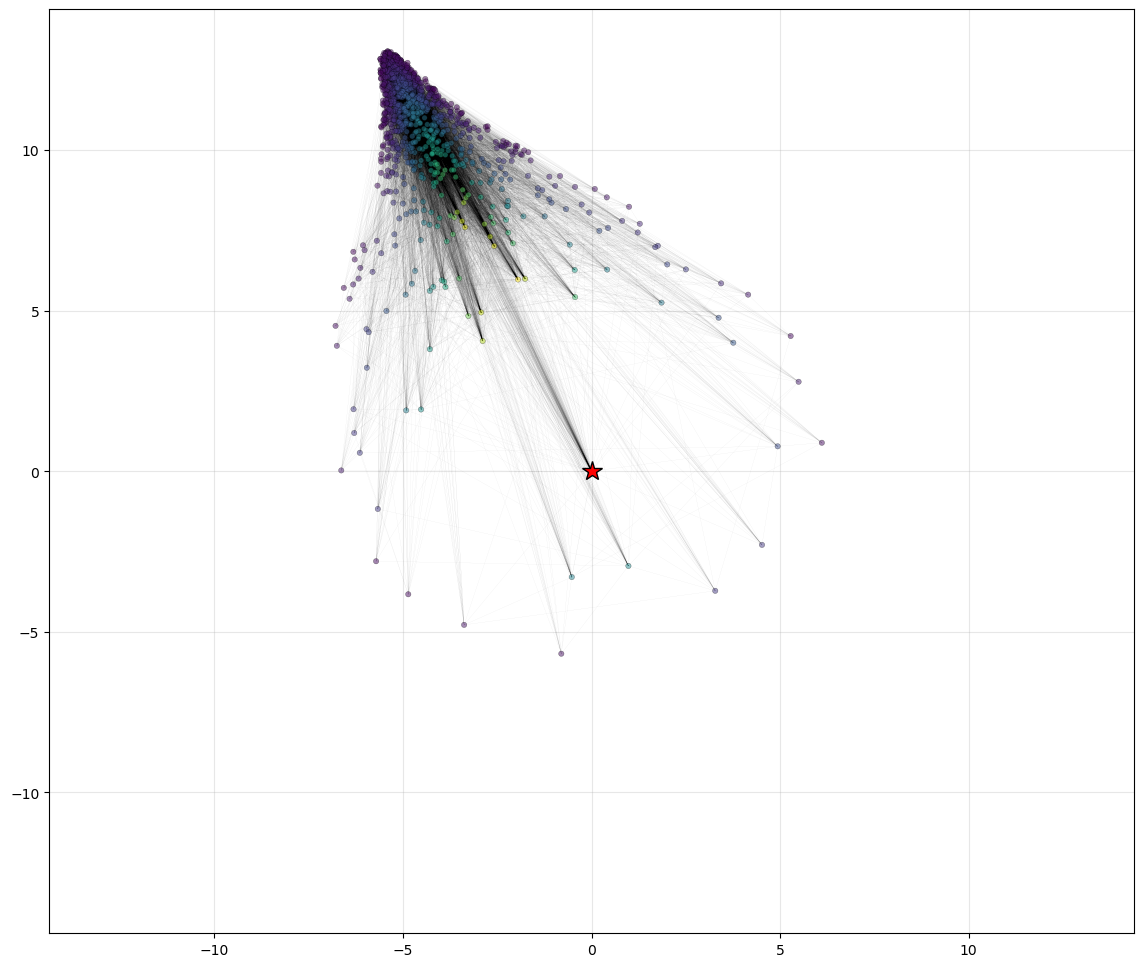

In [6]:
import pandas as pd
import pipeline.boost as boost
import pipeline.figures as figs
import numpy as np
df = dfba
G = Gba
start_node = data.get_most_popular_node(G)
selected = df[df['Vertex'] == start_node].iloc[0]
r, theta = selected['Disc.Radius'], selected['Inf.Theta']

r_changed, theta_changed = boost.centrar_en_origen(df['Disc.Radius'], df['Inf.Theta'], r, theta)
df2 = pd.DataFrame()
df2['Vertex'] = df['Vertex']
df2['Inf.Kappa'] = df['Inf.Kappa']
df2['Disc.Radius'] = r_changed
df2['Inf.Theta'] = theta_changed
df2['Disc.X'] = df2['Disc.Radius']*np.cos(df2['Inf.Theta'])
df2['Disc.Y'] = df2['Disc.Radius']*np.sin(df2['Inf.Theta'])
df = df2


figs.mercator_disc(df, [start_node], net=G)

# Epidèmia

In [21]:
output_batch_file_random = f"{working_folder}/batch_sir_evolution_random.txt"

infection_rates = [100]      # 1..100
random_seeds = range(1, 31)       # 1..60

recovery_rate = 1E-1
limit_time = 1E10
model_type = 2   # SIR_MODEL
n = 0

with open(output_batch_file_random, "w") as f:
    f.write("# infection_rate  recovery_rate  seed  limit_time  model_type start_node\n")
    for i in infection_rates:
        infection_rate = i / 100.0   # real(i_sim*2, dp)/100
        for j in random_seeds:
            seed = 42069 + j
            # Escribir línea con 5 valores (start_node opcional omitido)
            for k in range(1000):
                f.write(f"{infection_rate:.6f} {recovery_rate:.6f} {seed} {limit_time:.1f} {model_type} {k}\n")
                n = n+1

print(f"Archivo batch generado: {output_batch_file_random} con {n} simulaciones.")

Archivo batch generado: ./generated-nets/batch_sir_evolution_random.txt con 30000 simulaciones.


In [ ]:
import pandas as pd
import pipeline.hyperbolic as hyp
sets = [
    (Gba, dfba, paramsba, ba_edges_file),
    (Ger, dfer, paramser, er_edges_file),
    (Gconf, dfconf, paramsconf, conf_edges_file),
    (Gs1h2 , dfs1h2, paramss1h2, s1h2_edges_file)
]

for (G, df, params, edges_file) in sets:
    R = 2 * np.log(params['nb. vertices']/(params['mu']*np.pi*params['kappa_min']**2))


    edges = pd.DataFrame(G.edges, columns=['a', 'b'])
    edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='a', right_on='Vertex', suffixes=('_a', '_b'))
    edges = pd.merge(edges, df[['Vertex', 'Disc.Radius', 'Inf.Theta']], left_on='b', right_on='Vertex', suffixes=('_a', '_b'))
    edges['Theta_Dif'] = np.pi - np.abs(np.pi - np.abs(edges['Inf.Theta_a']-edges['Inf.Theta_b']))

    edges['Distance'] = np.where(edges['Theta_Dif'] == 0, 
                                np.abs(edges['Disc.Radius_a']- edges['Disc.Radius_b']), 
                                hyp.hyperbolic_distance_og(edges['Disc.Radius_a'], edges['Disc.Radius_b'], edges['Theta_Dif']))



    for n in range(10):
        c = -(n+1)/10
        edges['Epidemic_Func'] = hyp.link_probability_og(edges['Distance'], R, c)

        avg_epidemic_func = np.average(edges['Epidemic_Func'])

        edges['Weight_Multiplier'] = edges['Epidemic_Func']/avg_epidemic_func
        edges.to_csv(f"{edges_file}_weight_-{n+1}x10^-1", sep='\t', header=False, index=False, columns=['a', 'b', 'Weight_Multiplier'])

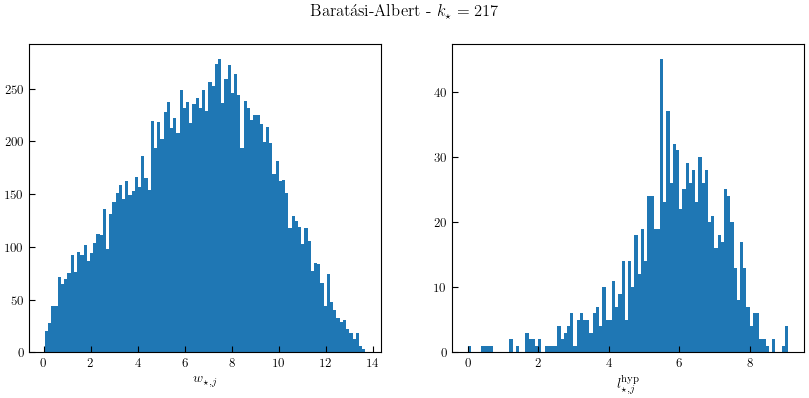

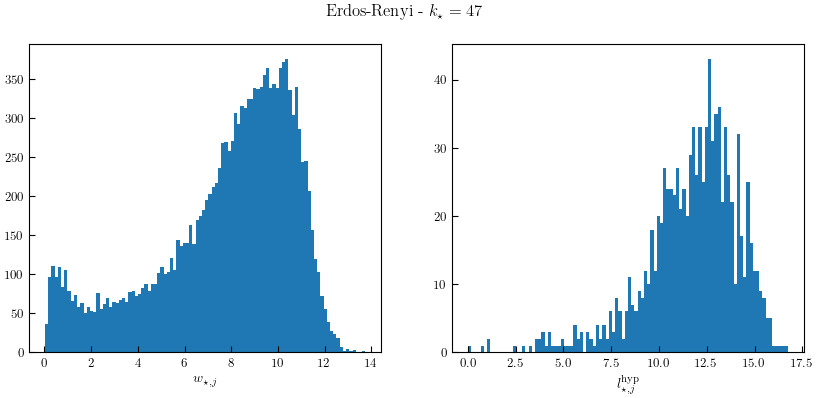

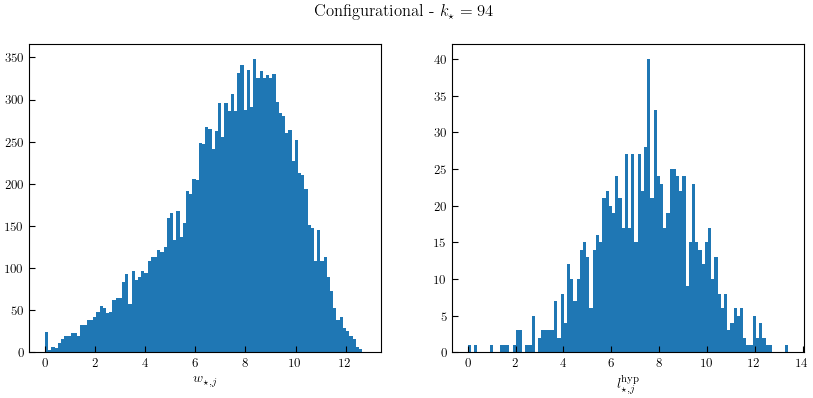

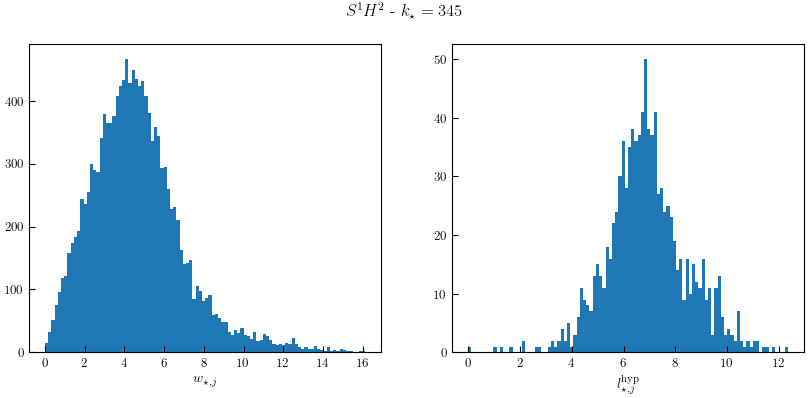

In [30]:
import networkx as nx
sets = [
    (Gba, dfba, 'Baratási-Albert'),
    (Ger, dfer, 'Erdos-Renyi'),
    (Gconf, dfconf, 'Configurational'),
    (Gs1h2 , dfs1h2, r'$S^1H^2$')
]

for (G, df, title) in sets:
    coords = (
        df.set_index('Vertex')
        [['Disc.Radius', 'Inf.Theta']]
        .to_dict('index')
    )

    for u, v in G.edges():
        
        r1 = coords[u]['Disc.Radius']
        t1 = coords[u]['Inf.Theta']

        r2 = coords[v]['Disc.Radius']
        t2 = coords[v]['Inf.Theta']

        d = hyp.hyperbolic_distance_og_thetas(r1, t1, r2, t2)

        G[u][v]['weight'] = d
    start_node = data.get_most_popular_node(G)
    weights = [
        G[u][v]['weight']
        for u,v in G.edges()
    ]

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4)) 

    ax1.hist(weights, bins=100)
    ax1.set_xlabel(r'$w_{\star,j}$')

    hyp_distance = nx.single_source_dijkstra_path_length(
        G,
        start_node,
        weight='weight'
    )

    hops_dist = nx.single_source_dijkstra_path_length(
        G,
        start_node,
        weight=None
    )
    
    ax2.hist(hyp_distance.values(), bins=100)
    ax2.set_xlabel(r'$l^\text{hyp}_{\star,j}$')
    deg = G.degree()[start_node]
    # ax3.hist(hops_dist.values(), bins=10)
    # ax3.set_xlabel(r'$l_\text{top}$')
    fig.suptitle(title + rf' - $k_\star = {deg}$')
    plt.show()